# YZM304 Proje 2 - SVHN ile CNN Kar??la?t?rmas?

Bu defterde SVHN veri seti ?zerinde ?? farkl? CNN yakla??m?n? ayn? ayarlarla kar??la?t?r?yorum. ?lk model basit bir referans CNN, ikincisi ayn? yap?n?n `BatchNorm` ve `Dropout` eklenmi? hali, ???nc?s? ise haz?r model olarak `ResNet18`.

?al??ma sonunda e?itim e?rileri, test sonu?lar? ve karma??kl?k matrisleri `artifacts/` klas?r?ne kaydediliyor.


## Bu notebookta ne var?

Bu k?s?m ?devin ilk ?? modelini kaps?yor.
- veri setinin haz?rlanmas?
- iki farkl? CNN'in a??k bi?imde yaz?lmas?
- haz?r mimari olarak `ResNet18` kullan?lmas?
- sonu?lar?n tablo ve grafik olarak kaydedilmesi

Hibrit model k?sm? ikinci notebookta devam ediyor: `02_hibrit_cnn_ml.ipynb`.


In [1]:
from pathlib import Path
import copy
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

try:
    from torchvision.models import resnet18, ResNet18_Weights
except ImportError:
    from torchvision.models import resnet18
    ResNet18_Weights = None

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_theme(style='whitegrid')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Kullanılan cihaz: {device}')


Kullanılan cihaz: cuda


## Deney Ayarlar?

Bu b?l?mde klas?r yap?s? ve temel hiperparametreler tan?mlan?yor. H?zl? deneme yapmak istersen ?nce epoch say?s?n? d???r?p son ko?uda tekrar art?rabilirsin.


In [2]:
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / 'data'
ARTIFACTS_DIR = PROJECT_DIR / 'artifacts'
FIGURES_DIR = ARTIFACTS_DIR / 'figures'
MODELS_DIR = ARTIFACTS_DIR / 'models'

for directory in [DATA_DIR, ARTIFACTS_DIR, FIGURES_DIR, MODELS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 1e-3
VALIDATION_RATIO = 0.1
NUM_WORKERS = 0
PIN_MEMORY = device.type == 'cuda'

CLASS_NAMES = [str(i) for i in range(10)]

print('Proje klasörü :', PROJECT_DIR)
print('Artifact klasörü:', ARTIFACTS_DIR)
print('Epoch sayısı   :', EPOCHS)


Proje klasörü : /content
Artifact klasörü: /content/artifacts
Epoch sayısı   : 10


## Veri Seti ve ?n ??leme

SVHN, ger?ek sokak g?r?nt?lerinden k?rp?lm?? rakam ?rneklerinden olu?uyor. G?rseller `32x32` ve `RGB`, yani k???k boyutlu CNN deneyleri i?in uygun bir veri seti.

Bu b?l?mde tensor d?n???m?, normalization ve validation ay?rma i?lemleri yap?l?yor.


In [3]:
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4377, 0.4438, 0.4728), (0.1980, 0.2010, 0.1970)),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4377, 0.4438, 0.4728), (0.1980, 0.2010, 0.1970)),
])

full_train_dataset = datasets.SVHN(root=DATA_DIR, split='train', download=True, transform=train_transform)
test_dataset = datasets.SVHN(root=DATA_DIR, split='test', download=True, transform=test_transform)

val_size = int(len(full_train_dataset) * VALIDATION_RATIO)
train_size = len(full_train_dataset) - val_size
train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED),
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print(f'Eğitim örneği     : {len(train_dataset)}')
print(f'Doğrulama örneği  : {len(val_dataset)}')
print(f'Test örneği       : {len(test_dataset)}')


100%|██████████| 182M/182M [00:13<00:00, 13.8MB/s]
100%|██████████| 64.3M/64.3M [00:06<00:00, 9.71MB/s]


Eğitim örneği     : 65932
Doğrulama örneği  : 7325
Test örneği       : 26032


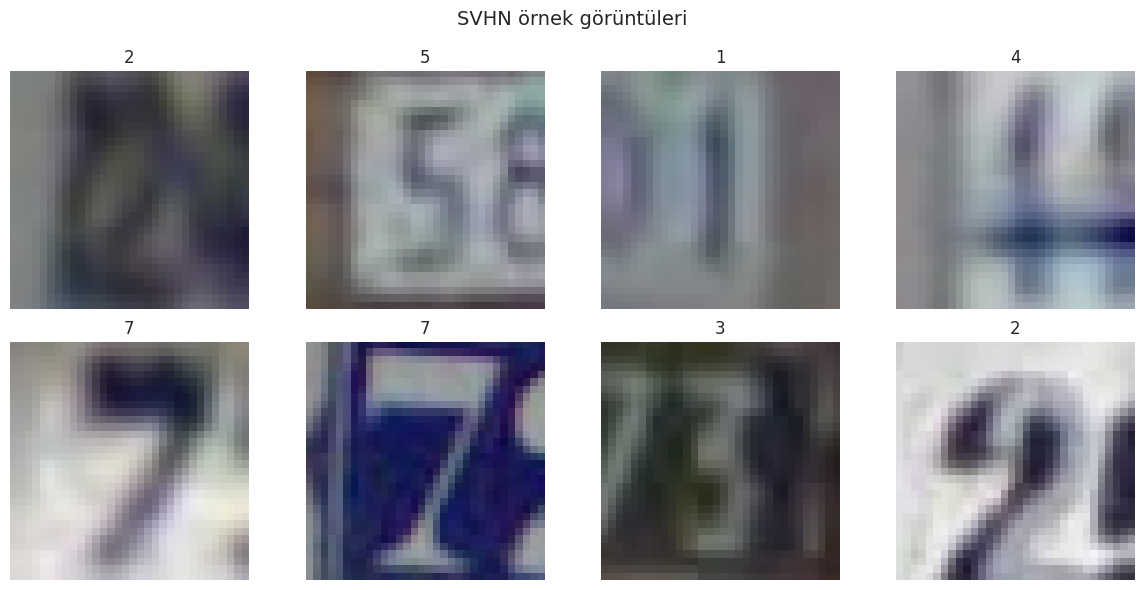

In [4]:
def denormalize(images):
    mean = torch.tensor((0.4377, 0.4438, 0.4728)).view(1, 3, 1, 1)
    std = torch.tensor((0.1980, 0.2010, 0.1970)).view(1, 3, 1, 1)
    return images * std + mean

images, labels = next(iter(train_loader))
images = denormalize(images[:8]).clamp(0, 1)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, image, label in zip(axes.flatten(), images, labels[:8]):
    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(CLASS_NAMES[int(label)])
    ax.axis('off')

plt.suptitle('SVHN örnek görüntüleri', fontsize=14)
plt.tight_layout()
plt.show()


## Model 1 - Temel CNN

?lk model sade bir referans model olarak b?rak?ld?. Katmanlar? a??k yaz?p temel yap?n?n tek ba??na ne yapt???n? g?rmek istedim.

Mimari:
- `Conv2d(3 -> 32)` + `ReLU` + `MaxPool`
- `Conv2d(32 -> 64)` + `ReLU` + `MaxPool`
- `Conv2d(64 -> 128)` + `ReLU` + `MaxPool`
- `Flatten`
- `Linear(2048 -> 256)` + `ReLU`
- `Linear(256 -> 10)`

Son katmanda ayr? bir `softmax` yok; kay?p hesab?nda do?rudan `CrossEntropyLoss` kullan?l?yor.


In [5]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

baseline_model = BaselineCNN()
print(baseline_model)


BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)


## Model 2 - ?yile?tirilmi? CNN

?kinci modelde ayn? omurga korunuyor; fark? olu?turan k?s?m ??renmeyi toparlayan ek katmanlar. B?ylece ilk modelle daha adil bir kar??la?t?rma yap?labiliyor.

Eklenenler:
- konvol?syon bloklar?ndan sonra `BatchNorm2d`
- s?n?fland?r?c? k?sm?nda `Dropout`

Beklenti, temel modele g?re daha kararl? e?itim ve biraz daha iyi genelleme elde etmek.


In [6]:
class ImprovedCNN(nn.Module):
    def __init__(self, num_classes=10, dropout_rate=0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout_rate),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

improved_model = ImprovedCNN()
print(improved_model)


ImprovedCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.3, inplace=False)
    (2): Linear(i

## Model 3 - Haz?r CNN Mimarisi

???nc? model olarak `ResNet18` kulland?m. SVHN k???k boyutlu oldu?u i?in ilk konvol?syon katman? ve maxpool k?sm? bu veri setine daha uygun olacak ?ekilde ayarland?.

Varsay?lan durumda model s?f?rdan e?itiliyor. ?stenirse daha sonra pretrained s?r?m de ayr?ca denenebilir.


In [7]:
def create_resnet18_svhn(num_classes=10, use_pretrained=False):
    if ResNet18_Weights is not None and use_pretrained:
        model = resnet18(weights=ResNet18_Weights.DEFAULT)
    else:
        model = resnet18(weights=None)

    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

resnet_model = create_resnet18_svhn()
print(resnet_model)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), p

## E?itim ve De?erlendirme Fonksiyonlar?

Ayn? e?itim d?ng?s?n? her model i?in kullanmak kar??la?t?rmay? daha temiz tutuyor. A?a??daki yard?mc? fonksiyonlar loss, accuracy, s?n?fland?rma raporu ve karma??kl?k matrisi ?retmek i?in ortak kullan?l?yor.


In [8]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (outputs.argmax(dim=1) == labels).sum().item()
        total_samples += batch_size

    return total_loss / total_samples, total_correct / total_samples


def evaluate(model, loader, criterion, device, collect_predictions=False):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            batch_size = labels.size(0)
            preds = outputs.argmax(dim=1)

            total_loss += loss.item() * batch_size
            total_correct += (preds == labels).sum().item()
            total_samples += batch_size

            if collect_predictions:
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

    results = {
        'loss': total_loss / total_samples,
        'accuracy': total_correct / total_samples,
    }

    if collect_predictions:
        results['predictions'] = np.array(all_preds)
        results['labels'] = np.array(all_labels)

    return results


def run_experiment(model_name, model_builder, train_loader, val_loader, test_loader, device, epochs=10, lr=1e-3):
    model = model_builder().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
    }

    best_val_acc = -1.0
    best_state = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_metrics = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_metrics['loss'])
        history['val_acc'].append(val_metrics['accuracy'])

        if val_metrics['accuracy'] > best_val_acc:
            best_val_acc = val_metrics['accuracy']
            best_state = copy.deepcopy(model.state_dict())

        print(
            f"[{model_name}] Epoch {epoch + 1:02d}/{epochs} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} val_acc={val_metrics['accuracy']:.4f}"
        )

    model.load_state_dict(best_state)
    model_path = MODELS_DIR / f"{model_name.lower().replace(' ', '_')}_best.pth"
    torch.save(model.state_dict(), model_path)

    test_metrics = evaluate(model, test_loader, criterion, device, collect_predictions=True)
    report = classification_report(
        test_metrics['labels'],
        test_metrics['predictions'],
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0,
    )
    cm = confusion_matrix(test_metrics['labels'], test_metrics['predictions'])

    return {
        'model': model,
        'history': history,
        'test_accuracy': test_metrics['accuracy'],
        'test_loss': test_metrics['loss'],
        'predictions': test_metrics['predictions'],
        'labels': test_metrics['labels'],
        'classification_report': report,
        'confusion_matrix': cm,
        'model_path': model_path,
    }


## E?itimlerin Ba?lat?lmas?

Bu b?l?m ?? modeli s?rayla e?itiyor ve ??kan dosyalar? `artifacts/` alt?nda topluyor.


In [9]:
experiments = {
    'Model 1 - Baseline CNN': lambda: BaselineCNN(num_classes=10),
    'Model 2 - Improved CNN': lambda: ImprovedCNN(num_classes=10, dropout_rate=0.3),
    'Model 3 - ResNet18': lambda: create_resnet18_svhn(num_classes=10, use_pretrained=False),
}

results = {}

for model_name, builder in experiments.items():
    print('=' * 100)
    results[model_name] = run_experiment(
        model_name=model_name,
        model_builder=builder,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        device=device,
        epochs=EPOCHS,
        lr=LEARNING_RATE,
    )

print('Eğitim tamamlandı.')


[Model 1 - Baseline CNN] Epoch 01/10 | train_loss=0.8836 train_acc=0.7177 | val_loss=0.4736 val_acc=0.8678
[Model 1 - Baseline CNN] Epoch 02/10 | train_loss=0.3957 train_acc=0.8845 | val_loss=0.3714 val_acc=0.8926
[Model 1 - Baseline CNN] Epoch 03/10 | train_loss=0.3075 train_acc=0.9094 | val_loss=0.3380 val_acc=0.9047
[Model 1 - Baseline CNN] Epoch 04/10 | train_loss=0.2552 train_acc=0.9262 | val_loss=0.3196 val_acc=0.9106
[Model 1 - Baseline CNN] Epoch 05/10 | train_loss=0.2171 train_acc=0.9367 | val_loss=0.3346 val_acc=0.9053
[Model 1 - Baseline CNN] Epoch 06/10 | train_loss=0.1864 train_acc=0.9445 | val_loss=0.3008 val_acc=0.9180
[Model 1 - Baseline CNN] Epoch 07/10 | train_loss=0.1503 train_acc=0.9552 | val_loss=0.3350 val_acc=0.9092
[Model 1 - Baseline CNN] Epoch 08/10 | train_loss=0.1272 train_acc=0.9628 | val_loss=0.3358 val_acc=0.9185
[Model 1 - Baseline CNN] Epoch 09/10 | train_loss=0.1056 train_acc=0.9674 | val_loss=0.3582 val_acc=0.9117
[Model 1 - Baseline CNN] Epoch 10/10 

In [10]:
comparison_rows = []
for model_name, result in results.items():
    comparison_rows.append({
        'Model': model_name,
        'Test Loss': result['test_loss'],
        'Test Accuracy': result['test_accuracy'],
        'Model Path': str(result['model_path']),
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
comparison_df.to_csv(ARTIFACTS_DIR / 'cnn_comparison_metrics.csv', index=False)
comparison_df


,Model,Test Loss,Test Accuracy,Model Path
0,Model 3 - ResNet18,0.247818,0.936194,/content/artifacts/models/model_3_-_resnet18_b...
1,Model 2 - Improved CNN,0.264609,0.925169,/content/artifacts/models/model_2_-_improved_c...
2,Model 1 - Baseline CNN,0.367370,0.910034,/content/artifacts/models/model_1_-_baseline_c...


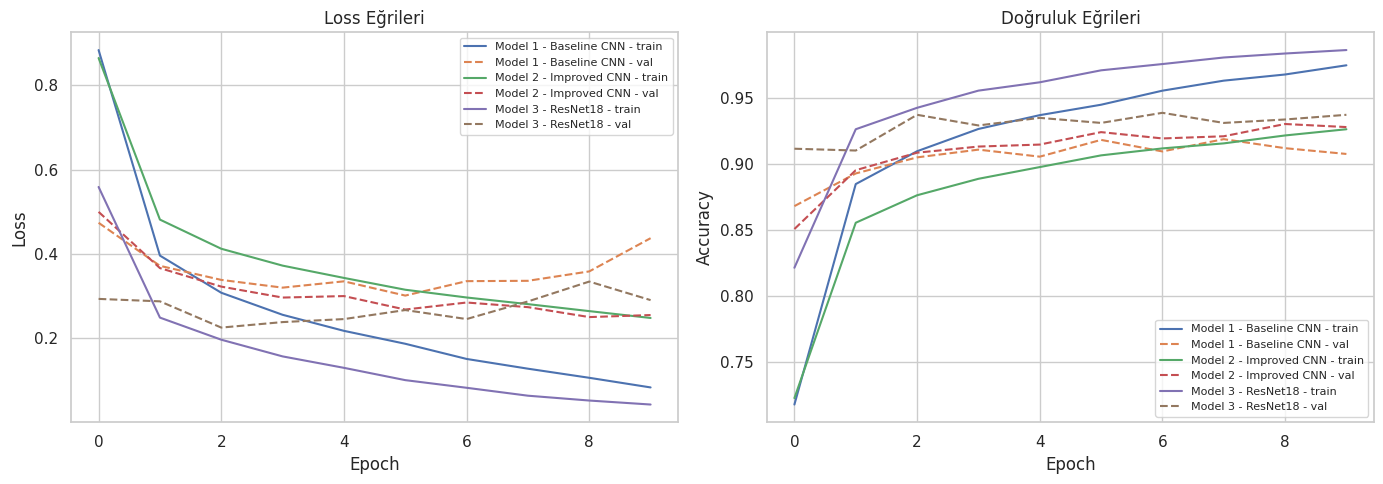

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for model_name, result in results.items():
    axes[0].plot(result['history']['train_loss'], label=f'{model_name} - train')
    axes[0].plot(result['history']['val_loss'], linestyle='--', label=f'{model_name} - val')
    axes[1].plot(result['history']['train_acc'], label=f'{model_name} - train')
    axes[1].plot(result['history']['val_acc'], linestyle='--', label=f'{model_name} - val')

axes[0].set_title('Loss Eğrileri')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=8)

axes[1].set_title('Doğruluk Eğrileri')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cnn_training_curves.png', dpi=200, bbox_inches='tight')
plt.show()


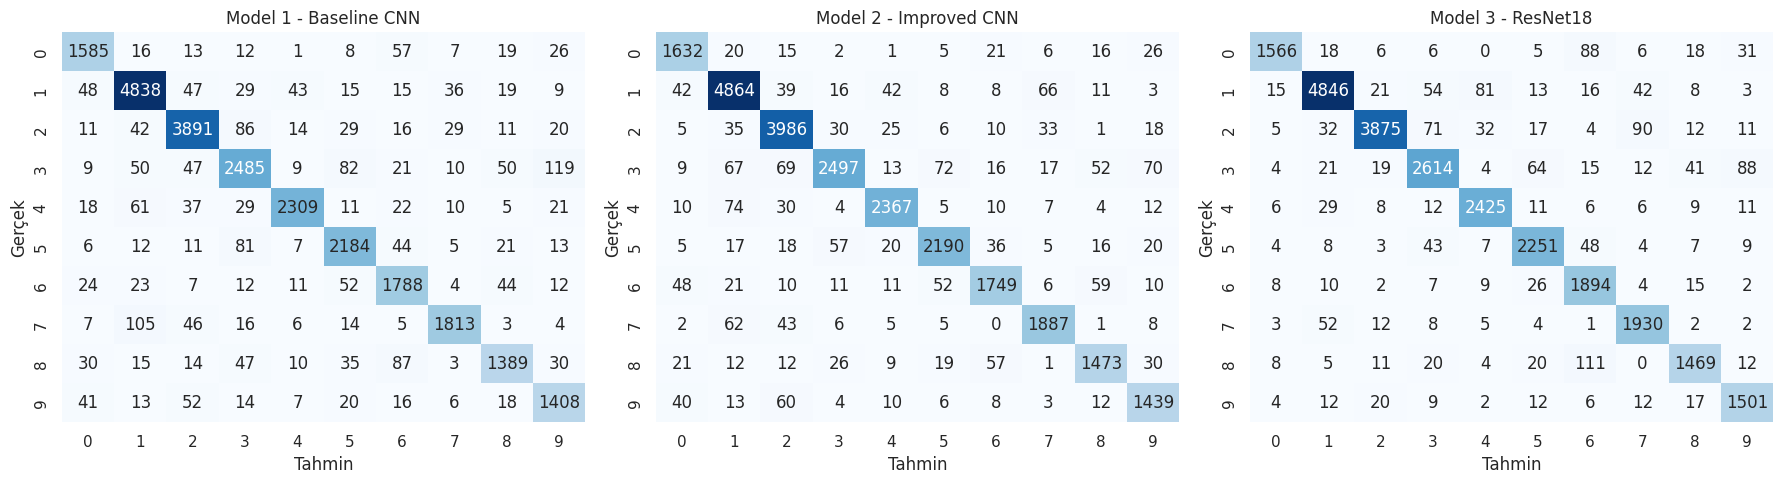

In [12]:
fig, axes = plt.subplots(1, len(results), figsize=(18, 5))
if len(results) == 1:
    axes = [axes]

for ax, (model_name, result) in zip(axes, results.items()):
    sns.heatmap(
        result['confusion_matrix'],
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        ax=ax,
    )
    ax.set_title(model_name)
    ax.set_xlabel('Tahmin')
    ax.set_ylabel('Gerçek')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cnn_confusion_matrices.png', dpi=200, bbox_inches='tight')
plt.show()


In [13]:
for model_name, result in results.items():
    print('=' * 120)
    print(model_name)
    print('-' * 120)
    print(result['classification_report'])


Model 1 - Baseline CNN
------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.8909    0.9088    0.8998      1744
           1     0.9349    0.9488    0.9418      5099
           2     0.9342    0.9378    0.9360      4149
           3     0.8840    0.8622    0.8730      2882
           4     0.9553    0.9152    0.9348      2523
           5     0.8914    0.9161    0.9036      2384
           6     0.8634    0.9044    0.8834      1977
           7     0.9428    0.8980    0.9198      2019
           8     0.8797    0.8367    0.8577      1660
           9     0.8472    0.8828    0.8646      1595

    accuracy                         0.9100     26032
   macro avg     0.9024    0.9011    0.9015     26032
weighted avg     0.9105    0.9100    0.9100     26032

Model 2 - Improved CNN
--------------------------------------------------------------------------

## Rapor Yazarken Bak?lacak Noktalar

Sonu?lar? yorumlarken ?zellikle ?unlara bakmak yeterli:
- en iyi do?rulu?u hangi model verdi
- `BatchNorm` ve `Dropout` eklemek ne kadar fark etti
- `ResNet18` neden ?ne ??kt? ya da hangi s?n?flarda zorland?
- karma??kl?k matrisinde hangi rakamlar daha ?ok kar??t?

Hibrit model k?sm? ikinci notebookta devam ediyor.


## Colab ??kt? ?ndirme

Colab'da drive ba?lamadan ?al??t?ysan, bu h?cre `artifacts/` klas?r?n? zipleyip do?rudan indiriyor.


In [14]:
import shutil

archive_base = PROJECT_DIR / 'svhn_cnn_karsilastirma_artifacts'
archive_path = shutil.make_archive(str(archive_base), 'zip', root_dir=ARTIFACTS_DIR)
print(f'ZIP oluşturuldu: {archive_path}')

try:
    from google.colab import files
    files.download(archive_path)
except ImportError:
    print('Colab dışı ortam algılandı. ZIP dosyası belirtilen klasöre kaydedildi.')


ZIP oluşturuldu: /content/svhn_cnn_karsilastirma_artifacts.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>